## Feature Engineering

This notebook focuses on creating business-oriented features for credit risk analysis.

The objective is to transform raw variables into meaningful indicators that support portfolio segmentation, risk assessment, and dashboard reporting.

In [10]:
import pandas as pd
df = pd.read_csv('financial_loan_clean.csv')
print('Df shape:',df.shape)
df.head()

Df shape: (38576, 31)


,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,loan_amount,total_acc,total_payment,loan_category,loan_defaut,loan_default,issue_year,issue_month,issue_month_name,issue_quarter
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,2500,4,1009,Bad Loan,1,1,2021,2,February,1
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,3000,4,3939,Good Loan,0,0,2021,1,January,1
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,12000,11,3522,Bad Loan,1,1,2021,1,January,1
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,4500,9,4911,Good Loan,0,0,2021,2,February,1
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,3500,28,3835,Good Loan,0,0,2021,1,January,1


In [ ]:
risk_cols = ['annual_income','dti','loan_amount','int_rate','grade','loan_default']
df[risk_cols].describe(include='all') # 'grade' = A,B,... -> 'all' (all types)

,annual_income,dti,loan_amount,int_rate,grade,loan_default
count,3.857600e+04,38576.000000,38576.000000,38576.000000,38576,38576.000000
unique,NaN,NaN,NaN,NaN,7,NaN
top,NaN,NaN,NaN,NaN,B,NaN
freq,NaN,NaN,NaN,NaN,11674,NaN
mean,6.964454e+04,0.133274,11296.066855,0.120488,NaN,0.138247
std,6.429368e+04,0.066662,7460.746022,0.037164,NaN,0.345163
min,4.000000e+03,0.000000,500.000000,0.054200,NaN,0.000000
25%,4.150000e+04,0.082100,5500.000000,0.093200,NaN,0.000000
50%,6.000000e+04,0.134200,10000.000000,0.118600,NaN,0.000000
75%,8.320050e+04,0.185900,15000.000000,0.145900,NaN,0.000000


--> Key Findings

- The portfolio default rate is 13.82%.
- Most borrowers earn between $40,000 and $80,000 annually.
- The average loan amount is approximately $11,300.
- Interest rates range from 5.4% to 24.6%.
- Grade B borrowers represent the largest segment of the portfolio.
- Annual income contains significant outliers that may require special treatment in future analyses.

1. Income Distribution Analysis

Before creating income segments, the distribution of annual income is analyzed to identify appropriate thresholds and detect potential outliers.

Quantile analysis helps define meaningful business categories for borrower segmentation and risk assessment.

In [19]:
quantiles = df['annual_income'].quantile([0.25,0.5,0.75,0.90,0.95,0.99])
print(quantiles)

0.25     41500.0
0.50     60000.0
0.75     83200.5
0.90    117000.0
0.95    144000.0
0.99    235000.0
Name: annual_income, dtype: float64


--> The annual income distribution is highly right-skewed and contains several extreme outliers.

Key quantiles:

- 25%: $41,500
- 50% (Median): $60,000
- 75%: $83,200
- 90%: $117,000
- 95%: $144,000
- 99%: $235,000

Most borrowers earn less than $235,000 per year, while a small number of high-income outliers reach several million dollars.

To improve visualization and focus on the typical borrower profile, incomes above the 99th percentile are excluded from the histogram. This approach provides a clearer understanding of the income distribution without modifying the original dataset.

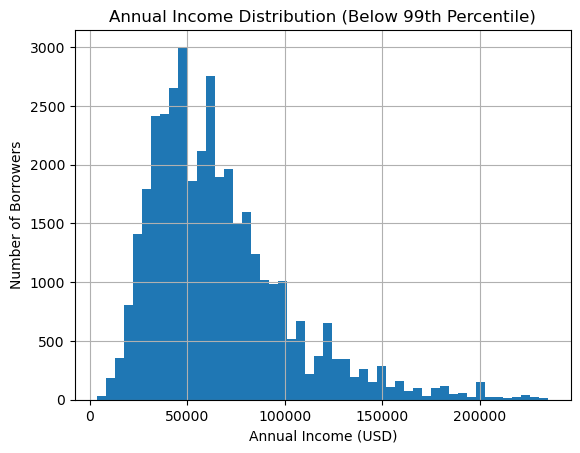

In [21]:
import matplotlib.pyplot as plt

income_limit = df['annual_income'].quantile(0.99)

df[df['annual_income'] < income_limit]['annual_income'].hist(bins=50)

plt.title('Annual Income Distribution (Below 99th Percentile)')
plt.xlabel('Annual Income (USD)')
plt.ylabel('Number of Borrowers')

plt.show()

2. Income Segmentation

Borrowers are grouped into income categories to facilitate portfolio analysis and identify potential relationships between income levels and credit risk.

The segmentation thresholds are based on the observed income distribution of the portfolio.

pd.cut() is used to transform a continuous numerical variable into categorical groups.

Income segmentation:
- Low Income: 0–40k
- Middle Income: 40k–80k
- Upper Income: 80k–150k
- High Income: >150k

In [29]:
df['income_band'] = pd.cut(
    df['annual_income'],
    bins=[0, 40000, 80000, 150000, float('inf')],
    labels=[
        'Low Income',
        'Middle Income',
        'Upper Income',
        'High Income'
    ]
)

#%
income_summary = pd.DataFrame({
    'count': df['income_band'].value_counts(),
    'percentage': df['income_band'].value_counts(normalize=True).mul(100).round(2)
})

print(income_summary)

               count  percentage
income_band                     
Middle Income  19037       49.35
Low Income      9274       24.04
Upper Income    8730       22.63
High Income     1535        3.98


Middle-income borrowers represent nearly half of the portfolio (49.4%), while high-income customers account for only 4.0%, indicating a typical retail lending customer base.

3. Default Rate by Income Segment

The default rate is analyzed across income groups to investigate whether borrower income influences credit risk.

In [37]:
income_default = df.groupby('income_band')['loan_default'].mean() * 100
income_default

/var/folders/lj/jmj0mxmj1_vftts3y7z557tr0000gn/T/ipykernel_71054/2617549579.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default = df.groupby('income_band')['loan_default'].mean() * 100


income_band
Low Income       17.090791
Middle Income    13.888743
Upper Income     10.813288
High Income      10.423453
Name: loan_default, dtype: float64

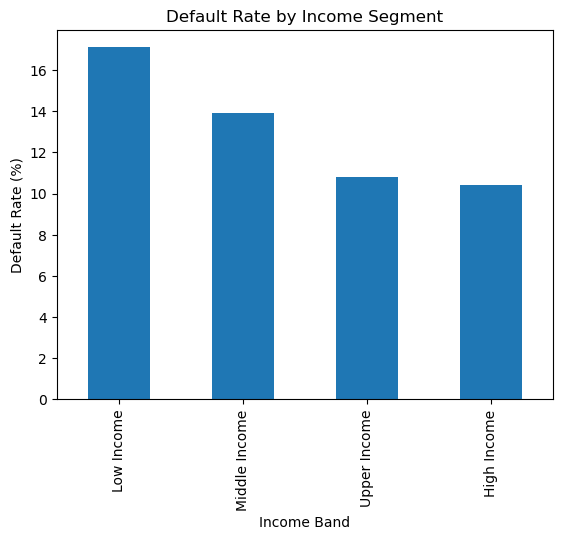

In [38]:
import matplotlib.pyplot as plt

income_default.plot(kind='bar')

plt.title('Default Rate by Income Segment')
plt.xlabel('Income Band')
plt.ylabel('Default Rate (%)')

plt.show()

4. Debt-to-Income (DTI) Analysis

The debt-to-income ratio is analyzed to evaluate borrowers' financial burden and its relationship with loan default risk.

In [35]:
df['dti'].describe()

count    38576.000000
mean         0.133274
std          0.066662
min          0.000000
25%          0.082100
50%          0.134200
75%          0.185900
max          0.299900
Name: dti, dtype: float64

- Mean (13.3%)--> On average, borrowers allocate 13.3% of their income to debt payments.
- Median (13.4%)--> Half of the borrowers have a DTI ratio below 13.4%.
- 25th Percentile (8.2%)--> 25% of borrowers have a DTI lower than 8.2%.
- 75th Percentile (18.6%)--> 75% of borrowers maintain a DTI below 18.6%.
- Maximum (30.0%)--> The highest DTI observed in the portfolio is 30%, indicating no extremely leveraged borrowers.

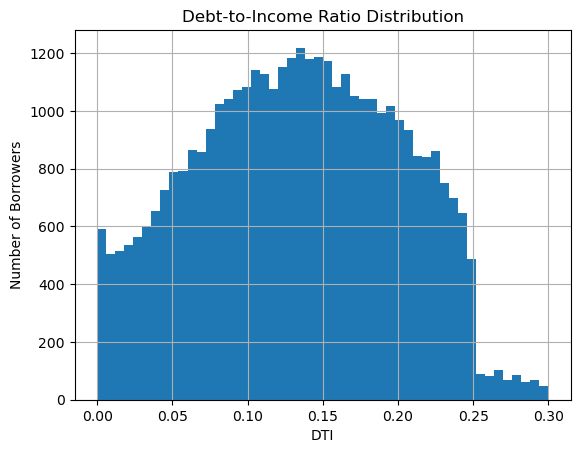

In [39]:
df['dti'].hist(bins=50)

plt.title('Debt-to-Income Ratio Distribution')
plt.xlabel('DTI')
plt.ylabel('Number of Borrowers')

plt.show()

The DTI distribution is concentrated between 5% and 25%, with most borrowers around 10%–18%.

This suggests that the portfolio is mainly composed of borrowers with moderate debt burden.

In [41]:
df['dti_band'] = pd.cut(
    df['dti'],
    bins=[0, 0.10, 0.20, 0.30],
    labels=[
        'Low DTI',
        'Moderate DTI',
        'High DTI'
    ],
    include_lowest=True
)

df['dti_band'].value_counts()

dti_band
Moderate DTI    18504
Low DTI         12803
High DTI         7269
Name: count, dtype: int64

- Low DTI (33.2%)--> Borrowers with a relatively low debt burden and stronger repayment capacity.
- Moderate DTI (48.0%)--> The largest group, representing borrowers with balanced debt levels.
- High DTI (18.8%)--> Borrowers with higher financial obligations and potentially greater credit risk.

In [42]:
dti_default = (
    df.groupby('dti_band', observed=True)['loan_default']
    .mean()
    .mul(100)
    .round(2)
)

print(dti_default)

dti_band
Low DTI         12.00
Moderate DTI    14.39
High DTI        15.60
Name: loan_default, dtype: float64


- Low DTI (12.00%)--> Borrowers with lower debt obligations show the lowest default rate.
- Moderate DTI (14.39%)--> Default risk increases as the debt burden becomes more significant.
- High DTI (15.60%)--> Borrowers with higher debt-to-income ratios exhibit the highest default rate, indicating greater credit risk.

=> Default rates are relatively low across all DTI groups (<20%), but they increase steadily with higher debt burdens.

5. Interest Rate Analysis

Interest rates are analyzed to understand their relationship with borrower risk and default behavior.

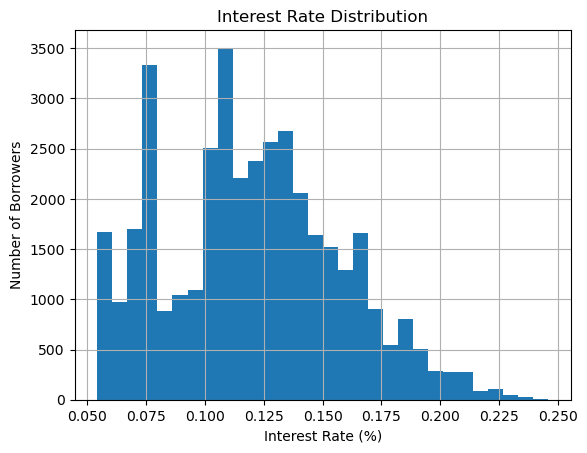

In [45]:
df['int_rate'].hist(bins=30)

plt.title('Interest Rate Distribution')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Number of Borrowers')

plt.show()

Most borrowers receive interest rates between 10% and 15%, while only a small proportion are charged rates above 20%.



In [58]:
interest_distribution = pd.DataFrame({
    'Number of Borrowers': df['interest_band'].value_counts(),
    'Percentage (%)': (
        df['interest_band']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})
interest_distribution = interest_distribution.reset_index()

interest_distribution.columns = [
    'Interest Rate Band',
    'Number of Borrowers',
    'Percentage (%)'
]

interest_distribution

,Interest Rate Band,Number of Borrowers,Percentage (%)
0,Moderate Rate,18349,47.57
1,Low Rate,11897,30.84
2,High Rate,7472,19.37
3,Very High Rate,858,2.22


interest_default:
The average default rate for each interest rate segment.

Purpose:
To analyze whether higher interest rates are associated with higher credit risk.

In [59]:
# Do borrowers paying higher interest rates exhibit higher default probabilities??
interest_default = (
    df.groupby('interest_band', observed=True)['loan_default']
    .mean()
    .mul(100)
    .round(2)
)

print(interest_default)

interest_band
Low Rate           6.35
Moderate Rate     13.97
High Rate         23.07
Very High Rate    33.68
Name: loan_default, dtype: float64


In [65]:
interest_summary = df.groupby('interest_band', observed=True).agg(
    **{
        'Number of Borrowers': ('loan_default', 'count'),
        'Number of Defaults': ('loan_default', 'sum')
    }
)

interest_summary['Default Rate (%)'] = (
    interest_summary['Number of Defaults']
    / interest_summary['Number of Borrowers']
    * 100
).round(2)

interest_summary

,Number of Borrowers,Number of Defaults,Default Rate (%)
interest_band,,,
Low Rate,11897,756,6.35
Moderate Rate,18349,2564,13.97
High Rate,7472,1724,23.07
Very High Rate,858,289,33.68


Default rates increase sharply with interest rates, from 6.35% for low-rate loans to 33.68% for very high-rate loans.

This suggests that higher-risk borrowers are typically charged higher interest rates.

6. Loan Amount Analysis

Loan amounts are analyzed to investigate whether larger loans are associated with higher default risk.

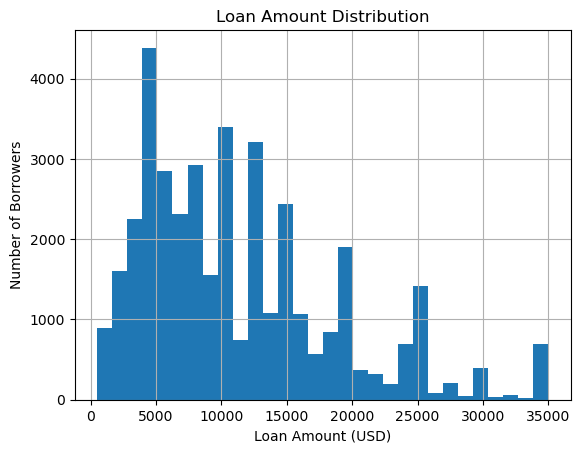

In [66]:
df['loan_amount'].hist(bins=30)

plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount (USD)')
plt.ylabel('Number of Borrowers')

plt.show()

In [67]:
df['loan_band'] = pd.cut(
    df['loan_amount'],
    bins=[0, 5000, 10000, 20000, float('inf')],
    labels=[
        'Small Loan',
        'Medium Loan',
        'Large Loan',
        'Very Large Loan'
    ],
    include_lowest=True
)

In [68]:
loan_summary = df.groupby('loan_band', observed=True).agg(
    **{
        'Number of Borrowers': ('loan_default', 'count'),
        'Number of Defaults': ('loan_default', 'sum')
    }
)

loan_summary['Default Rate (%)'] = (
    loan_summary['Number of Defaults']
    / loan_summary['Number of Borrowers']
    * 100
).round(2)

loan_summary

,Number of Borrowers,Number of Defaults,Default Rate (%)
loan_band,,,
Small Loan,9113,1189,13.05
Medium Loan,12578,1555,12.36
Large Loan,12349,1748,14.15
Very Large Loan,4536,841,18.54


Borrowers with very large loans exhibit the highest default rate, indicating a potential relationship between loan size and credit risk.

7. Credit Grade Analysis

Credit grades are analyzed to evaluate how the bank's internal risk ratings relate to borrower default behavior.

In [69]:
grade_distribution = pd.DataFrame({
    'Number of Borrowers': df['grade'].value_counts(),
    'Percentage (%)': (
        df['grade']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

grade_distribution

,Number of Borrowers,Percentage (%)
grade,,
B,11674,30.26
A,9689,25.12
C,7904,20.49
D,5182,13.43
E,2786,7.22
F,1028,2.66
G,313,0.81


In [70]:
grade_summary = df.groupby('grade').agg(
    **{
        'Number of Borrowers': ('loan_default', 'count'),
        'Number of Defaults': ('loan_default', 'sum')
    }
)

grade_summary['Default Rate (%)'] = (
    grade_summary['Number of Defaults']
    / grade_summary['Number of Borrowers']
    * 100
).round(2)

grade_summary

,Number of Borrowers,Number of Defaults,Default Rate (%)
grade,,,
A,9689,552,5.70
B,11674,1343,11.50
C,7904,1266,16.02
D,5182,1072,20.69
E,2786,691,24.80
F,1028,311,30.25
G,313,98,31.31


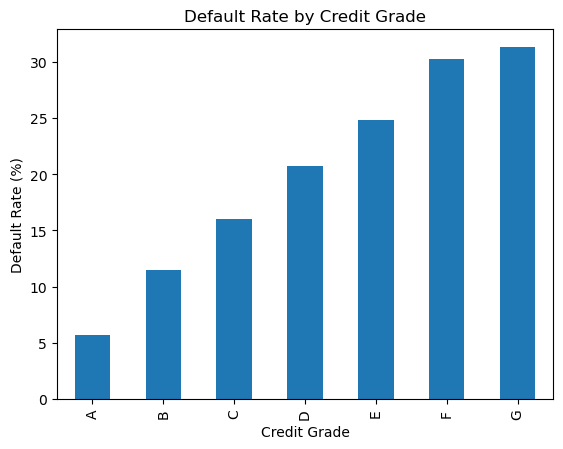

In [71]:
grade_summary['Default Rate (%)'].plot(kind='bar')

plt.title('Default Rate by Credit Grade')
plt.xlabel('Credit Grade')
plt.ylabel('Default Rate (%)')

plt.show()

Lower credit grades are associated with higher default rates, indicating a strong relationship between credit quality and repayment behavior.

8. Home Ownership Analysis

Home ownership status is analyzed to examine its relationship with borrower default risk.

In [ ]:
# Distribution
home_distribution = pd.DataFrame({
    'Number of Borrowers': df['home_ownership'].value_counts(),
    'Percentage (%)': (
        df['home_ownership']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

home_distribution

,Number of Borrowers,Percentage (%)
home_ownership,,
RENT,18439,47.80
MORTGAGE,17198,44.58
OWN,2838,7.36
OTHER,98,0.25
NONE,3,0.01


In [ ]:
# Summary + Default Rate
home_summary = df.groupby('home_ownership').agg(
    **{
        'Number of Borrowers': ('loan_default', 'count'),
        'Number of Defaults': ('loan_default', 'sum')
    }
)

home_summary['Default Rate (%)'] = (
    home_summary['Number of Defaults']
    / home_summary['Number of Borrowers']
    * 100
).round(2)

home_summary

,Number of Borrowers,Number of Defaults,Default Rate (%)
home_ownership,,,
MORTGAGE,17198,2231,12.97
NONE,3,0,0.00
OTHER,98,18,18.37
OWN,2838,397,13.99
RENT,18439,2687,14.57


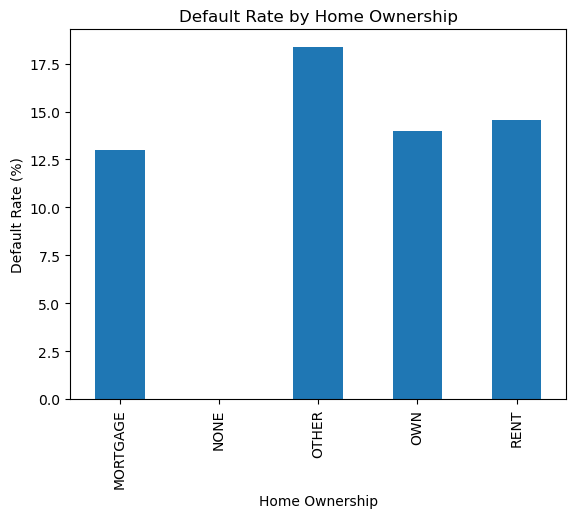

In [74]:
home_summary['Default Rate (%)'].plot(kind='bar')

plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate (%)')

plt.show()

Borrowers with mortgages have the lowest default rate (12.97%), while renters show slightly higher risk (14.57%).

The "OTHER" category has the highest default rate (18.37%), but the sample size is very small (98 borrowers), so the result may not be representative.

9. Employment Length Analysis

Employment length is analyzed to investigate whether work experience influences borrower default behavior.

In [75]:
employment_distribution = pd.DataFrame({
    'Number of Borrowers': df['emp_length'].value_counts(),
    'Percentage (%)': (
        df['emp_length']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

employment_distribution

,Number of Borrowers,Percentage (%)
emp_length,,
10+ years,8870,22.99
< 1 year,4575,11.86
2 years,4382,11.36
3 years,4088,10.60
4 years,3428,8.89
5 years,3273,8.48
1 year,3229,8.37
6 years,2228,5.78
7 years,1772,4.59


In [76]:
employment_summary = df.groupby('emp_length').agg(
    **{
        'Number of Borrowers': ('loan_default', 'count'),
        'Number of Defaults': ('loan_default', 'sum')
    }
)

employment_summary['Default Rate (%)'] = (
    employment_summary['Number of Defaults']
    / employment_summary['Number of Borrowers']
    * 100
).round(2)

employment_summary

,Number of Borrowers,Number of Defaults,Default Rate (%)
emp_length,,,
1 year,3229,445,13.78
10+ years,8870,1322,14.90
2 years,4382,561,12.80
3 years,4088,548,13.41
4 years,3428,454,13.24
5 years,3273,449,13.72
6 years,2228,306,13.73
7 years,1772,262,14.79
8 years,1476,200,13.55


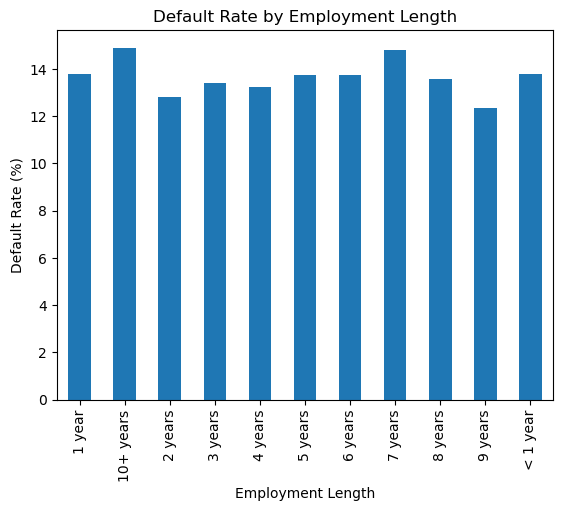

In [77]:
employment_summary['Default Rate (%)'].plot(kind='bar')

plt.title('Default Rate by Employment Length')
plt.xlabel('Employment Length')
plt.ylabel('Default Rate (%)')

plt.show()

Default rates remain relatively stable across employment lengths, ranging from 12% to 15%.

This suggests that employment tenure alone is not a strong predictor of borrower default risk in this dataset.

10. Loan Purpose Analysis

Loan purposes are analyzed to determine whether certain borrowing needs are associated with higher default risk.

In [78]:
purpose_distribution = pd.DataFrame({
    'Number of Borrowers': df['purpose'].value_counts(),
    'Percentage (%)': (
        df['purpose']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

purpose_distribution

,Number of Borrowers,Percentage (%)
purpose,,
Debt consolidation,18214,47.22
credit card,4998,12.96
other,3824,9.91
home improvement,2876,7.46
major purchase,2110,5.47
small business,1776,4.60
car,1497,3.88
wedding,928,2.41
medical,667,1.73


In [79]:
purpose_summary = df.groupby('purpose').agg(
    **{
        'Number of Borrowers': ('loan_default', 'count'),
        'Number of Defaults': ('loan_default', 'sum')
    }
)

purpose_summary['Default Rate (%)'] = (
    purpose_summary['Number of Defaults']
    / purpose_summary['Number of Borrowers']
    * 100
).round(2)

purpose_summary

,Number of Borrowers,Number of Defaults,Default Rate (%)
purpose,,,
Debt consolidation,18214,2651,14.55
car,1497,155,10.35
credit card,4998,508,10.16
educational,315,50,15.87
home improvement,2876,327,11.37
house,366,57,15.57
major purchase,2110,206,9.76
medical,667,100,14.99
moving,559,84,15.03


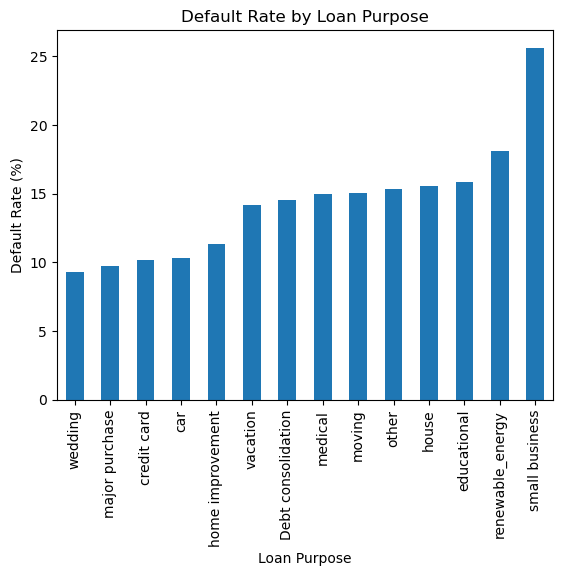

In [80]:
purpose_summary['Default Rate (%)'].sort_values().plot(kind='bar')

plt.title('Default Rate by Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Default Rate (%)')

plt.show()

Loan purpose appears to be an important risk factor.

Borrowers seeking loans for business activities tend to have substantially higher default rates than those borrowing for consumption purposes such as weddings, cars, or major purchases.